cuda


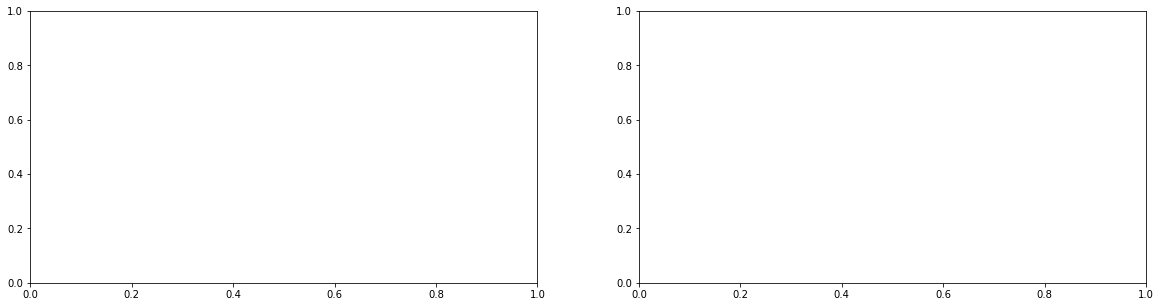

In [1]:
import os
import sys
import time
import copy
sys.path.append('../SLM/')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import json
import math
import random

import fnmatch
import re
from itertools import product, groupby

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from tokenizers import Tokenizer

import models, init, train, measures
import importlib
# Reload the modules
importlib.reload( models)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

def collect(path, prefix, *keys):

    all_entries = os.listdir(path)
    matching_entries = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
#                 params = re.findall(r'_P(\d+)', ending)
#                 assert params, f'{entry}: trainsize p not found!'
                array = re.findall(r'_(\d+)', ending)
                matching_entries.append({
                    'ending': ending,
#                     'P': int(params[0]),
                    'seed': int(array[0])
                })
#     matching_entries.sort(key=lambda x: [x.get('P'), x.get('exp')])
    return matching_entries


def find_all(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params


def find_lowest(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params[0]


def get_loss(path, prefix):

    loss_list = []

    p_list = find_all(path, prefix, 'P')
    print('training set sizes: ', p_list)

    for  p in p_list:

        bs = find_lowest(path, prefix, 'bs', f'P{p}_')
        print(f'P={p}, batch size={bs}')
        collection = collect( path, prefix, f'P{p}_', f'bs{bs}_')
        loss = []

        for entry in collection:
            try:
                results = torch.load(path+prefix+entry['ending'])
                print(p, results['best']['loss'])
                loss.append(results['best']['loss'])

            except:
                print(path+prefix+entry['ending']+f' not found.')


        print(f'{len(loss)} exps. , mean loss {torch.tensor(loss).mean()}')
        loss_list.append(torch.tensor(loss))
    return loss_list


fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

# $P=2^{16}$

768 2 1e-4 1.0 tensor(nan) tensor(nan)
768 2 1e-4 2.0 tensor(4.2954) tensor(0.0075)
768 2 1e-4 4.0 tensor(4.2082) tensor(0.0237)
768 2 1e-4 8.0 tensor(4.2934) tensor(0.0224)
768 2 3e-4 1.0 tensor(nan) tensor(nan)
768 2 3e-4 2.0 tensor(4.2000) tensor(0.0218)
768 2 3e-4 4.0 tensor(4.1685) tensor(0.0113)
768 2 3e-4 8.0 tensor(4.2781) tensor(0.0233)
768 2 1e-3 1.0 tensor(4.2602) tensor(0.0062)
768 2 1e-3 2.0 tensor(4.2417) tensor(0.0247)
768 2 1e-3 4.0 tensor(4.3824) tensor(0.0476)
768 2 1e-3 8.0 tensor(4.4089) tensor(0.0199)
768 4 3e-4 2.0 tensor(4.2426) tensor(0.0162)
768 4 3e-4 4.0 tensor(4.1796) tensor(0.0100)
768 4 3e-4 8.0 tensor(4.2654) tensor(0.0202)
768 4 1e-3 2.0 tensor(4.2277) tensor(0.0235)
768 4 1e-3 4.0 tensor(4.2418) tensor(0.0157)
768 4 1e-3 8.0 tensor(4.4021) tensor(0.0353)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=4$)')

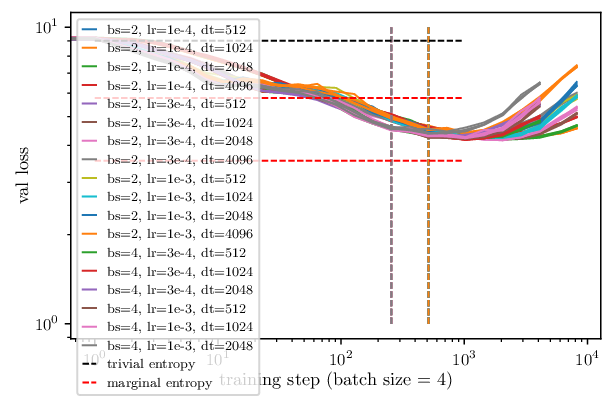

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 64
P = 65536
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 2
for lr in ['1e-4', '3e-4', '1e-3']:
    for dt in [ 512, 1024, 2048, 4096]:
 
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
for lr in ['3e-4', '1e-3']:
    for dt in [512, 1024, 2048]:
 
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')

ax.plot([1e0,1e3],[3.55,3.55], 'r--')

ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{18}$

768 4 1e-3 2.0 tensor(3.5719) tensor(0.0142)
768 4 1e-3 4.0 tensor(3.5610) tensor(0.0367)
768 4 1e-3 8.0 tensor(3.6797) tensor(0.0251)
768 8 3e-4 2.0 tensor(3.6760) tensor(0.0192)
768 8 3e-4 4.0 tensor(3.5470) tensor(0.0130)
768 8 3e-4 8.0 tensor(3.5999) tensor(0.0220)
768 8 3e-4 16.0 tensor(nan) tensor(nan)
768 8 1e-3 2.0 tensor(3.6265) tensor(0.0242)
768 8 1e-3 4.0 tensor(3.5232) tensor(0.0141)
768 8 1e-3 8.0 tensor(3.6687) tensor(0.0328)
768 8 1e-3 16.0 tensor(3.6885) tensor(0.0406)
768 8 3e-3 2.0 tensor(3.7482) tensor(0.0350)
768 8 3e-3 4.0 tensor(3.6654) tensor(0.0102)
768 8 3e-3 8.0 tensor(3.7171) tensor(0.0399)
768 8 3e-3 16.0 tensor(nan) tensor(nan)
768 16 1e-3 2.0 tensor(3.6689) tensor(0.0165)
768 16 1e-3 4.0 tensor(3.5852) tensor(0.0137)
768 16 1e-3 8.0 tensor(3.6232) tensor(0.0191)
768 16 1e-3 16.0 tensor(3.6959) tensor(0.0182)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=16$)')

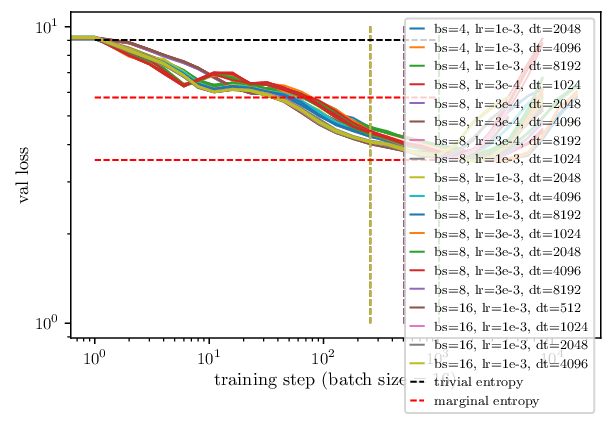

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 64
P = 262144
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 4
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
for lr in ['3e-4', '1e-3', '3e-3']:
    for dt in [1024, 2048, 4096, 8192]:
 
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


bs = 16
lr = '1e-3'
dt = 512
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')

ax.plot([1e0,1e3],[3.55,3.55], 'r--')

ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{18}$ : bs=8, lr=1e-3, dt=2048 (4 ep)

# $P=2^{20}$

768 4 1e-4 1.0 tensor(nan) tensor(nan)
768 4 1e-4 2.0 tensor(nan) tensor(nan)
768 4 1e-4 4.0 tensor(2.8955) tensor(0.0172)
768 4 1e-4 8.0 tensor(nan) tensor(nan)
768 4 3e-4 1.0 tensor(2.9277) tensor(0.0118)
768 4 3e-4 2.0 tensor(2.8430) tensor(0.0126)
768 4 3e-4 4.0 tensor(2.8052) tensor(0.0135)
768 4 3e-4 8.0 tensor(2.8949) tensor(0.0153)
768 4 1e-3 1.0 tensor(2.9118) tensor(0.0209)
768 4 1e-3 2.0 tensor(2.8314) tensor(0.0149)
768 4 1e-3 4.0 tensor(2.8800) tensor(0.0212)
768 4 1e-3 8.0 tensor(2.9120) tensor(0.0102)
768 8 1e-4 1.0 tensor(nan) tensor(nan)
768 8 1e-4 2.0 tensor(3.0518) tensor(0.0088)
768 8 1e-4 4.0 tensor(2.9425) tensor(0.0072)
768 8 1e-4 8.0 tensor(2.9524) tensor(0.0249)
768 8 3e-4 1.0 tensor(nan) tensor(nan)
768 8 3e-4 2.0 tensor(2.8595) tensor(0.0148)
768 8 3e-4 4.0 tensor(2.7918) tensor(0.0218)
768 8 3e-4 8.0 tensor(2.8924) tensor(0.0072)
768 8 1e-3 1.0 tensor(2.8929) tensor(0.0109)
768 8 1e-3 2.0 tensor(2.8472) tensor(0.0043)
768 8 1e-3 4.0 tensor(2.8472) tensor(0.0

Text(0.5, 0, 'training step (batch size $=16$)')

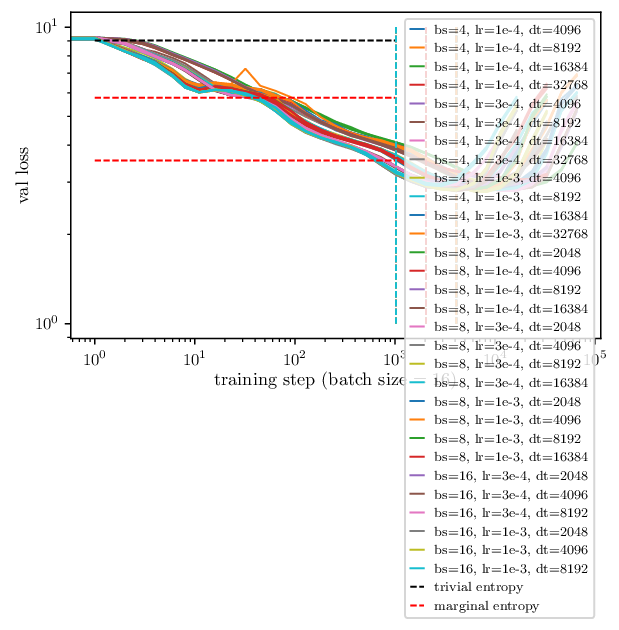

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 64
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 4
for lr in ['1e-4', '3e-4', '1e-3']:
    for dt in [4096, 8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')
    
bs = 8
for lr in ['1e-4', '3e-4', '1e-3']:
    for dt in [2048, 4096, 8192, 16384]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
for lr in [ '3e-4', '1e-3']:
    for dt in [2048, 4096, 8192]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.55,3.55], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

## Best at $P=2^{20}$ : bs=8, lr=3e-4, dt=8192 (4 ep)

768 8 1e-3 1.0 tensor(2.8929) tensor(0.0109)
768 8 1e-3 2.0 tensor(2.8844) tensor(0.0185)
768 8 1e-3 4.0 tensor(2.9737) tensor(0.0046)


Text(0.5, 0, 'training step (batch size $=8$)')

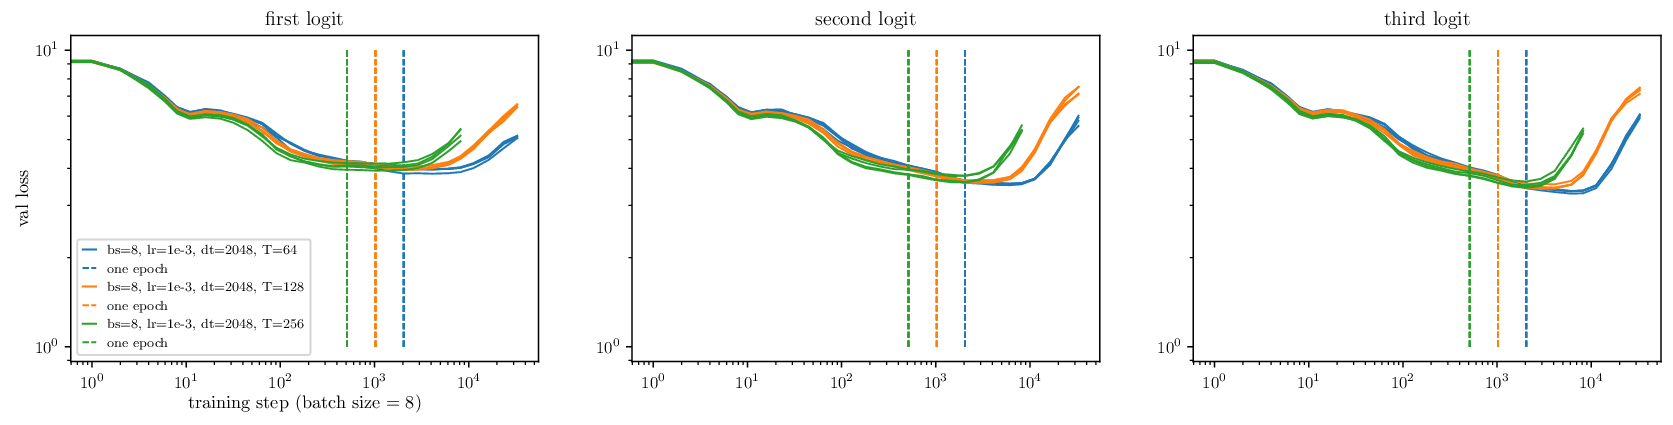

In [10]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 3, figsize=(3*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 64
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 8
for lr in ['1e-3']:
    for dt in [2048]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            for n in range(3):
                ax[n].plot([d['t'] for d in dynamics], [d['ngram_loss'][n] for d in dynamics], f'C{i}')
                ax[n].plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, T={T}')
        custom_lines.append(Line2D([0], [0], color=f'C{i}', linestyle='dashed'))
        custom_labels.append(fr'one epoch')
        
T = 128
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 8
for lr in ['1e-3']:
    for dt in [2048]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            for n in range(3):
                ax[n].plot([d['t'] for d in dynamics], [d['ngram_loss'][n] for d in dynamics], f'C{i}')
                ax[n].plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')

            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, T={T}')
        custom_lines.append(Line2D([0], [0], color=f'C{i}', linestyle='dashed'))
        custom_labels.append(fr'one epoch')

        
T = 256
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 8
for lr in ['1e-3']:
    for dt in [2048]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            for n in range(3):
                ax[n].plot([d['t'] for d in dynamics], [d['ngram_loss'][n] for d in dynamics], f'C{i}')
                ax[n].plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')

            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, T={T}')
        custom_lines.append(Line2D([0], [0], color=f'C{i}', linestyle='dashed'))
        custom_labels.append(fr'one epoch')

# ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
# custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
# custom_labels.append(fr'trivial entropy')

# marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
# marginal = torch.from_numpy(marginal)
# marg_ent = torch.masked_select(marginal, (marginal>0))
# print(marg_ent.size())
# marg_ent = -(marg_ent*marg_ent.log()).sum()
# print(marg_ent)
# ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
# custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
# custom_labels.append(fr'marginal entropy')


# ax.plot([1e0,1e3],[3.55,3.55], 'r--')


ax[0].legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax[0].set_xscale('log')
# ax.set_ylim(1.,5.)
ax[0].set_yscale('log')
ax[0].set_title(r'first logit')

ax[1].set_xscale('log')
# ax.set_ylim(1.,5.)
ax[1].set_yscale('log')
ax[1].set_title(r'second logit')

ax[2].set_xscale('log')
# ax.set_ylim(1.,5.)
ax[2].set_yscale('log')
ax[2].set_title(r'third logit')


ax[0].set_ylabel(fr'val loss', fontsize=11)
ax[0].set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

In [11]:
fig.savefig('tinystories/'+f'234gram-losses_tinystories.BPE8192_varT.pdf')

# $P=2^{22}$

768 8 1e-4 2.0 tensor(2.4420) tensor(0.0097)
768 8 1e-4 4.0 tensor(2.3834) tensor(0.0092)
768 8 1e-4 8.0 tensor(2.4123) tensor(0.0108)
768 8 3e-4 2.0 tensor(2.3171) tensor(0.0149)
768 8 3e-4 4.0 tensor(2.2913) tensor(0.0170)
768 8 3e-4 8.0 tensor(2.3480) tensor(0.0149)
768 16 1e-4 2.0 tensor(2.5034) tensor(0.0137)
768 16 1e-4 4.0 tensor(2.4269) tensor(0.0187)
768 16 1e-4 8.0 tensor(2.4472) tensor(0.0037)
768 16 3e-4 2.0 tensor(2.3298) tensor(0.0172)
768 16 3e-4 4.0 tensor(2.2906) tensor(0.0143)
768 16 3e-4 8.0 tensor(2.3505) tensor(0.0059)
768 16 1e-3 2.0 tensor(2.3501) tensor(0.0074)
768 16 1e-3 4.0 tensor(2.3186) tensor(0.0060)
768 16 1e-3 8.0 tensor(2.3782) tensor(0.0144)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=16$)')

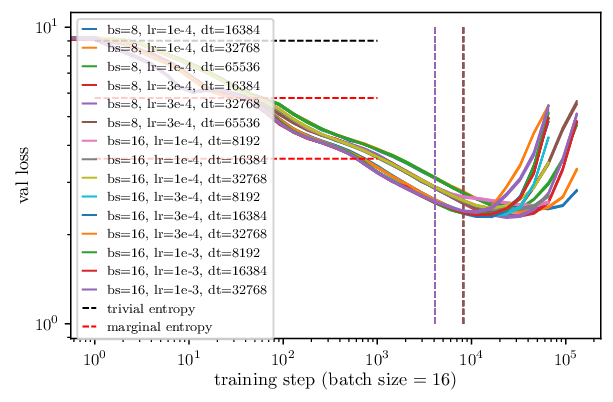

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 64
P = 4194304
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 8
for lr in [ '1e-4', '3e-4']:
    for dt in [16384, 32768, 65536]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
for lr in [ '1e-4', '3e-4', '1e-3']:
    for dt in [8192, 16384, 32768]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{22}$ : bs=16, lr=3e-4, dt=16384 (4 ep)

# $P=2^{24}$

# ALLSTARS

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1
T = 256

P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

bs = 2
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 4194304
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

bs = 8
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 16777216
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

bs = 4
lr = '3e-4'
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)